# 📊 Análisis Predictivo GAC — Agosto 2026
### Notebook consolidado que reproduce las slides de la presentación *"Propuesta de Mejora en Conversión de Ventas"*

**Pipeline:**
1. Carga y limpieza de las bases (Citas Digital + Bitácora de Piso)
2. Transformación de variables (booleanos → binarios, % → numérico, estandarización de asesores)
3. **Slide A:** Embudo de conversión
4. **Modelo logístico:** ¿Quién compra? (AUC, odds ratios) → base de los puntos 4 y 5 de la propuesta
5. **Slide B:** Regresión lineal múltiple — Ventas por asesor (R² = 0.862)
6. Diagnósticos del modelo (VIF, residuos, Shapiro-Wilk)
7. **Slide C:** Proyección de impacto con los coeficientes del modelo

> **Instrucciones:** coloca este notebook en la misma carpeta que los CSV de GAC y ejecuta celda por celda (Shift + Enter). El código detecta los archivos automáticamente por palabra clave, sin importar variaciones en el nombre.

## 0. Importar librerías

In [ ]:
# !pip install pandas numpy matplotlib seaborn statsmodels scikit-learn scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import confusion_matrix, roc_curve, auc
from scipy import stats
import glob, os, warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
print('Librerías listas ✓')

Librerías listas ✓


## 1. Carga de bases
El código busca los CSV **por palabra clave** en la carpeta del notebook, así funciona aunque el nombre tenga espacios o variaciones.

In [2]:
# =====================================================
# CARGA DE BASES
# =====================================================
# Los CSV que ves en el Explorer de VS Code estan en tu carpeta
# "Regresiones-simples". El notebook los puede leer directo de ahi.
#
# OPCION A (recomendada): arrastra este .ipynb dentro de la carpeta
#   Regresiones-simples en el Explorer y deja CARPETA_DATOS = '.'
#
# OPCION B: deja el notebook donde esta y edita esta linea con la
#   ruta de la carpeta donde estan los CSV (clic derecho a la carpeta
#   en el Explorer > Copy Path):
# CARPETA_DATOS = r'/Users/gabrielomarperezhernandez/Downloads/Regresiones-simples'

import unicodedata

CARPETA_DATOS = '.'   # '.' = la carpeta desde donde se ejecuta el notebook

def _norm(s):
    """Quita acentos y pasa a minusculas para comparar nombres de archivo."""
    return ''.join(ch for ch in unicodedata.normalize('NFD', str(s).lower())
                   if unicodedata.category(ch) != 'Mn')

print('Carpeta de trabajo:', os.path.abspath(CARPETA_DATOS))
todos_csv = glob.glob(os.path.join(CARPETA_DATOS, '**', '*.csv'), recursive=True)
print(f'CSV detectados ({len(todos_csv)}):')
for f in todos_csv:
    print('  -', f)

def find_csv(*keywords):
    '''Busca un CSV cuyo nombre contenga TODAS las palabras clave
    (sin importar acentos ni mayusculas).'''
    kws = [_norm(k) for k in keywords]
    for f in todos_csv:
        if all(k in _norm(os.path.basename(f)) for k in kws):
            return f
    return None

def load_csv(*keywords):
    f = find_csv(*keywords)
    if f is None:
        raise FileNotFoundError(
            f'No se encontro CSV con: {keywords}.\n'
            f'Revisa la lista de arriba. Si no aparecen los archivos GAC, '
            f'edita CARPETA_DATOS con la ruta de la carpeta Regresiones-simples.')
    try:
        df = pd.read_csv(f, encoding='utf-8', low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(f, encoding='latin-1', low_memory=False)
    print(f'\n✓ Cargado: {os.path.basename(f)}  →  {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

citas_raw = load_csv('citas', 'digital')
bit_raw   = load_csv('bitacora', 'piso')

Carpeta de trabajo: /Users/gabrielomarperezhernandez/Desktop/Carpeta Local Clase/Regresiones-simples
CSV detectados (12):
  - ./Analisis GAC Full7agosto 2026(Citas Digital).csv
  - ./Analisis GAC Full7agosto 2026(TOPS MKT).csv
  - ./Analisis GAC Full7agosto 2026(Base de Leads).csv
  - ./Analisis GAC Full7agosto 2026(Leads Reales).csv
  - ./Analisis GAC Full7agosto 2026(Bitacora de Piso).csv
  - ./Analisis GAC Full7agosto 2026(Base de Tlaxcala).csv
  - ./Leads_Reales_Depurado.csv
  - ./Analisis GAC Full7agosto 2026(TOPS TDH).csv
  - ./car_crashes.csv
  - ./Analisis GAC Full7agosto 2026(TOPS VENTAS).csv
  - ./Analisis GAC Full7agosto 2026(TOPS POST VENTA).csv
  - ./Analisis GAC Full7agosto 2026(Analisis de Piso ).csv

✓ Cargado: Analisis GAC Full7agosto 2026(Citas Digital).csv  →  1048575 filas x 16 columnas

✓ Cargado: Analisis GAC Full7agosto 2026(Bitacora de Piso).csv  →  234 filas x 30 columnas


## 2. Limpieza y transformación de datos

**Problemas de las bases crudas y su solución:**

| Problema | Solución |
|---|---|
| Citas Digital trae ~1,048,575 filas (residuo de Excel), solo 668 son reales | `dropna(how='all')` + quitar filas sin nombre de cliente |
| PDM / SDC / Venta vienen como texto `'TRUE'`/`'FALSE'` | Convertir a binario 1/0 (`PDM_bin`, `SDC_bin`, `Venta_bin`) |
| 'Potencial de compra' viene como texto con `%` | Quitar `%`, convertir a número, imputar nulos con la mediana |
| Asesores con nombres inconsistentes ('Mauricio Vazquez', 'Mauricio Vázquez', 'Mauricio') | Diccionario de equivalencias → `Asesor_std` |

In [3]:
# ---------- CITAS DIGITAL (base principal: funnel + modelos) ----------
cit = citas_raw.copy()
cit.columns = cit.columns.str.strip()
cit = cit.dropna(how='all')
cit = cit[cit['Nombre Cliente'].notna()].copy()   # quita las ~1M de filas fantasma de Excel

# Booleanos (texto) -> binario
for col in ['PDM', 'SDC', 'Venta']:
    cit[col] = cit[col].astype(str).str.strip().str.upper()
    cit[col + '_bin'] = (cit[col] == 'TRUE').astype(int)

# Potencial de compra: '75%' -> 75.0
cit['Potencial_num'] = pd.to_numeric(
    cit['Potencial de compra'].astype(str).str.replace('%', '', regex=False),
    errors='coerce')
cit['Potencial_num'] = cit['Potencial_num'].fillna(cit['Potencial_num'].median())

# Estandarizar nombres de asesores
asesor_map = {
    'Aurelio': 'Aurelio', 'Aurelio Torres': 'Aurelio',
    'Mauricio': 'Mauricio', 'Mauricio Vazquez': 'Mauricio', 'Mauricio Vázquez': 'Mauricio',
    'Pedro': 'Pedro', 'Pedro González': 'Pedro', 'Pedro Gonzalez': 'Pedro',
    'Victor': 'Victor', 'Alan': 'Alan', 'Alan González': 'Alan', 'Alan Gonzalez': 'Alan',
    'Ricardo': 'Ricardo', 'Cesar': 'Cesar', 'Cesar De Jesus': 'Cesar', 'Cesar De Jesús': 'Cesar',
    'Nancy': 'Nancy', 'Saul': 'Saul', 'Saúl': 'Saul',
    'Jorge': 'Jorge', 'Jorge Luis': 'Jorge', 'Antonio': 'Antonio',
    'Marco': 'Marco', 'Marco Antonio': 'Marco'}
cit['Asesor_std'] = (cit['Asesor Asignado'].astype(str).str.strip().str.title()
                     .map(asesor_map)
                     .fillna(cit['Asesor Asignado'].astype(str).str.strip().str.title()))

print(f'Citas Digital limpia: {cit.shape[0]} leads reales')

Citas Digital limpia: 668 leads reales


In [16]:
# ---------- BITÁCORA DE PISO (respalda el punto 5: intervención de gerente) ----------
bit = bit_raw.copy()
bit.columns = bit.columns.str.strip()
bit = bit.dropna(how='all', axis=1).dropna(how='all')
bit = bit[bit['Nombre Cliente'].notna()].copy()

def clean_bool(col):
    mapping = {True: 1, False: 0, 'True': 1, 'False': 0, 'TRUE': 1, 'FALSE': 0}
    return col.map(mapping).fillna(0).astype(int)

bit['PDM_bin'] = clean_bool(bit['PDM'])
bit['SDC_bin'] = clean_bool(bit['SDC'])
bit['Venta_bin'] = clean_bool(bit['Venta'])
bit['InterGerente_bin'] = clean_bool(bit['Inter Gerente'])
bit['Asesor_std'] = (bit['Asesor'].astype(str).str.strip().str.title()
                     .map(asesor_map)
                     .fillna(bit['Asesor'].astype(str).str.strip().str.title()))

print(f'Bitácora limpia: {bit.shape[0]} registros')
print(f'Ventas: {bit["Venta_bin"].sum()} | PDM: {bit["PDM_bin"].sum()} | SDC: {bit["SDC_bin"].sum()} | Inter. Gerente: {bit["InterGerente_bin"].sum()}')

Bitácora limpia: 197 registros
Ventas: 4 | PDM: 75 | SDC: 4 | Inter. Gerente: 31


---
## 3. SLIDE A — Contexto: Embudo de Conversión Actual
Conteo directo sobre Citas Digital (no requiere modelo). De aquí salen los 4 números del funnel y la gráfica de barras horizontales.

EMBUDO DE CONVERSIÓN — AGOSTO 2026
Leads totales : 668 (100%)
PDM realizada : 339 (50.7%)
SDC solicitada: 275 (41.2%)
Venta concret.: 58 (8.7%)


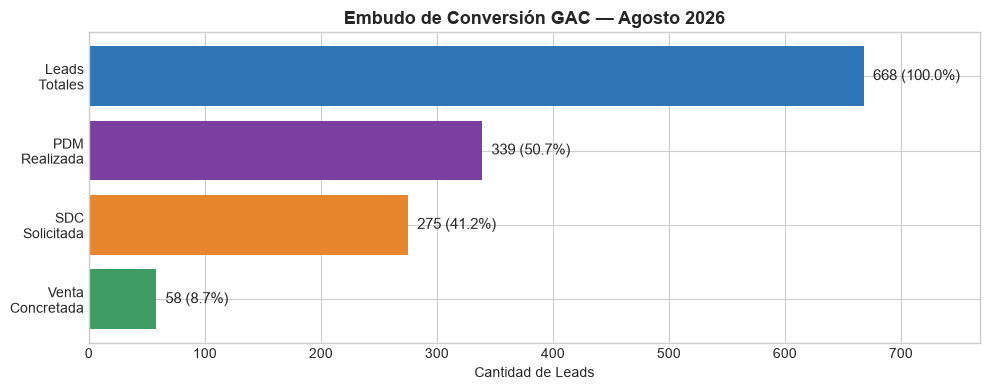

In [4]:
n   = len(cit)
pdm = cit['PDM_bin'].sum()
sdc = cit['SDC_bin'].sum()
vta = cit['Venta_bin'].sum()

print('EMBUDO DE CONVERSIÓN — AGOSTO 2026')
print('=' * 40)
print(f'Leads totales : {n} (100%)')
print(f'PDM realizada : {pdm} ({pdm/n*100:.1f}%)')
print(f'SDC solicitada: {sdc} ({sdc/n*100:.1f}%)')
print(f'Venta concret.: {vta} ({vta/n*100:.1f}%)')

etapas  = ['Leads\nTotales', 'PDM\nRealizada', 'SDC\nSolicitada', 'Venta\nConcretada']
vals    = [n, pdm, sdc, vta]
pcts    = [f'{v/n*100:.1f}%' for v in vals]
colores = ['#2E75B6', '#7B3FA0', '#E8862D', '#3D9B63']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(etapas[::-1], vals[::-1], color=colores[::-1])
for b, v, p in zip(bars, vals[::-1], pcts[::-1]):
    ax.text(b.get_width() + 8, b.get_y() + b.get_height()/2, f'{v} ({p})', va='center', fontsize=11)
ax.set_xlabel('Cantidad de Leads')
ax.set_title('Embudo de Conversión GAC — Agosto 2026', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(vals) * 1.15)
plt.tight_layout()
plt.savefig('slide_A_embudo_conversion.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 4. Modelo logístico — ¿Quién compra?
Respalda la slide **"Modelo Predictivo"** y los **puntos 4 y 5** de la propuesta (alertas tempranas por score).

*Decisión técnica (v5 del análisis original):* el modelo usa solo **3 variables clave** (PDM, SDC, Potencial). Las variables dummy de asesor/estatus impedían la convergencia del modelo, por lo que se descartaron.

In [5]:
X_log = cit[['PDM_bin', 'SDC_bin', 'Potencial_num']].copy()
y_log = cit['Venta_bin'].copy()
X_log_const = sm.add_constant(X_log)

logit_model = sm.Logit(y_log, X_log_const)
result_logit = logit_model.fit(disp=0, method='bfgs', maxiter=1000)
print(result_logit.summary())

                           Logit Regression Results                           
Dep. Variable:              Venta_bin   No. Observations:                  668
Model:                          Logit   Df Residuals:                      664
Method:                           MLE   Df Model:                            3
Date:                Mon, 07 Sep 2026   Pseudo R-squ.:                  0.2097
Time:                        18:21:42   Log-Likelihood:                -155.81
converged:                       True   LL-Null:                       -197.15
Covariance Type:            nonrobust   LLR p-value:                 8.170e-18
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -10.1902      1.329     -7.667      0.000     -12.795      -7.585
PDM_bin           0.8428      0.346      2.438      0.015       0.165       1.520
SDC_bin           1.4138      0.349     

In [6]:
# Odds Ratios: efecto multiplicativo sobre la probabilidad de compra
odds = pd.DataFrame({
    'Variable': X_log_const.columns,
    'Coeficiente': result_logit.params,
    'Odds Ratio': np.exp(result_logit.params),
    'p_value': result_logit.pvalues,
    'Significativo (p<0.05)': result_logit.pvalues < 0.05})
print(odds.round(4).to_string(index=False))

# AUC y accuracy
y_prob = result_logit.predict(X_log_const)
fpr, tpr, _ = roc_curve(y_log, y_prob)
roc_auc = auc(fpr, tpr)
acc = ((y_prob >= 0.5).astype(int) == y_log).mean()
print(f'\nAUC = {roc_auc:.3f}   |   Accuracy = {acc*100:.1f}%')
print('\n→ De aquí salen: SDC multiplica odds x4.1 | PDM x2.3 | Potencial +8.6% por punto')

     Variable  Coeficiente  Odds Ratio  p_value  Significativo (p<0.05)
        const     -10.1902      0.0000   0.0000                    True
      PDM_bin       0.8428      2.3228   0.0148                    True
      SDC_bin       1.4138      4.1114   0.0001                    True
Potencial_num       0.0829      1.0864   0.0000                    True

AUC = 0.815   |   Accuracy = 91.3%

→ De aquí salen: SDC multiplica odds x4.1 | PDM x2.3 | Potencial +8.6% por punto


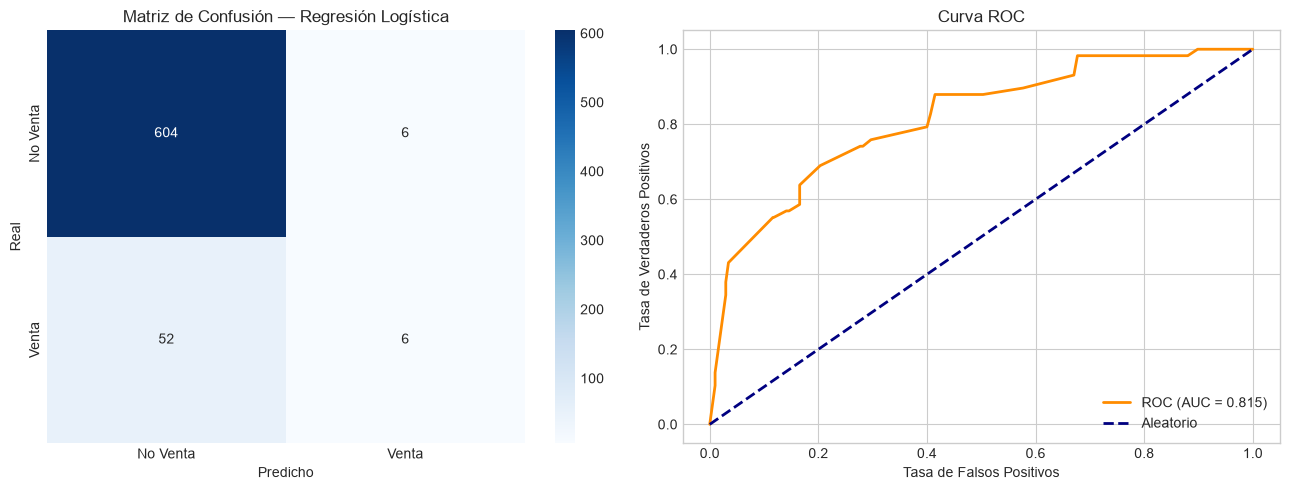

In [7]:
# Gráficas de evaluación: matriz de confusión + curva ROC
y_pred_class = (y_prob >= 0.5).astype(int)
cm = confusion_matrix(y_log, y_pred_class)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Venta', 'Venta'], yticklabels=['No Venta', 'Venta'])
axes[0].set_title('Matriz de Confusión — Regresión Logística')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predicho')

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos'); axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC'); axes[1].legend(loc='lower right')
plt.tight_layout()
plt.savefig('slide_modelo_logistico_evaluacion.png', dpi=300, bbox_inches='tight')
plt.show()

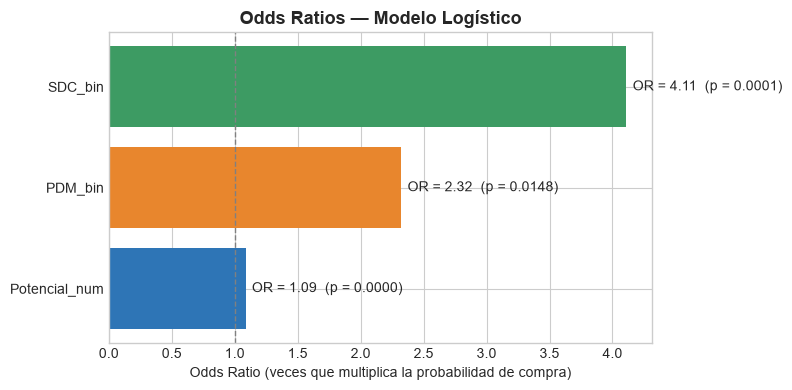

Ejemplo de scores (5 leads al azar):
           Nombre Cliente  PDM_bin  SDC_bin  Potencial_num  Score_Compra  Venta_bin
               Luis Lopez        0        0           70.0         0.012          0
Gabriel  Franco , Vazquez        0        0           60.0         0.005          0
      Juan José castellon        0        0           80.0         0.028          0
 Miguel Antonio Fernandez        0        0           70.0         0.012          0
       Victor  Lorenzana         1        1           65.0         0.073          0


In [8]:
# Gráfica de Odds Ratios (la que acompaña la slide "Impacto de cada Variable")
or_plot = odds[odds['Variable'] != 'const'].sort_values('Odds Ratio')
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(or_plot['Variable'], or_plot['Odds Ratio'],
        color=['#2E75B6', '#E8862D', '#3D9B63'][:len(or_plot)])
for i, (v, p) in enumerate(zip(or_plot['Odds Ratio'], or_plot['p_value'])):
    ax.text(v + 0.05, i, f'OR = {v:.2f}  (p = {p:.4f})', va='center', fontsize=10)
ax.axvline(1, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Odds Ratio (veces que multiplica la probabilidad de compra)')
ax.set_title('Odds Ratios — Modelo Logístico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('slide_odds_ratios.png', dpi=300, bbox_inches='tight')
plt.show()

# Score de probabilidad por lead (base del sistema de alertas tempranas, punto 4)
cit['Score_Compra'] = y_prob
print('Ejemplo de scores (5 leads al azar):')
print(cit[['Nombre Cliente', 'PDM_bin', 'SDC_bin', 'Potencial_num', 'Score_Compra', 'Venta_bin']]
      .sample(5, random_state=42).round(3).to_string(index=False))

---
## 5. SLIDE B — Modelo de Desempeño: Ventas por Asesor (R² = 0.862)

**Transformación clave:** se cambia la unidad de análisis de *nivel lead* a *nivel asesor* mediante `groupby`. Solo se incluyen asesores con ≥ 3 leads (estabilidad estadística).

In [9]:
asesor_agg = cit.groupby('Asesor_std').agg(
    Ventas=('Venta_bin', 'sum'),
    Total_Leads=('Venta_bin', 'count'),
    Total_PDM=('PDM_bin', 'sum'),
    Total_SDC=('SDC_bin', 'sum'),
    Potencial_Prom=('Potencial_num', 'mean')).reset_index()

asesor_agg = asesor_agg[asesor_agg['Total_Leads'] >= 3].copy()
print(f'Asesores en el modelo: {len(asesor_agg)}')
print(asesor_agg.sort_values('Ventas', ascending=False).head(10).round(2).to_string(index=False))

Asesores en el modelo: 28
   Asesor_std  Ventas  Total_Leads  Total_PDM  Total_SDC  Potencial_Prom
        Pedro      13           81         48         42           73.46
     Mauricio      11           98         47         39           71.73
       Victor       9           71         41         37           75.28
         Alan       4           45         28         16           73.89
      Aurelio       4           81         37         43           75.12
Pedro Antonio       3           31         14         15           71.77
 Mario Varela       2            4          3          2           56.25
      Ricardo       2           23         12         10           72.17
       Marcos       1            8          3          3           71.25
         Omar       1            9          1          9           77.78


In [10]:
X_asesor = asesor_agg[['Total_Leads', 'Total_PDM', 'Total_SDC', 'Potencial_Prom']].reset_index(drop=True)
y_asesor = asesor_agg['Ventas'].reset_index(drop=True)
X_asesor_const = sm.add_constant(X_asesor)

modelo_lineal = sm.OLS(y_asesor, X_asesor_const).fit()
print(modelo_lineal.summary())

tabla_coef = pd.DataFrame({
    'Variable': X_asesor.columns,
    'Coeficiente': modelo_lineal.params[1:].values,
    'p_value': modelo_lineal.pvalues[1:].values,
    'Significativo (p<0.05)': modelo_lineal.pvalues[1:].values < 0.05})
print('\nTABLA DE LA SLIDE (R² = %.3f):' % modelo_lineal.rsquared)
print(tabla_coef.round(4).to_string(index=False))
print('\n→ Insight clave: Total_Leads NO predice ventas (p = %.3f); Total_PDM SÍ (p = %.3f)'
      % (modelo_lineal.pvalues['Total_Leads'], modelo_lineal.pvalues['Total_PDM']))

                            OLS Regression Results                            
Dep. Variable:                 Ventas   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     35.54
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           1.56e-09
Time:                        18:21:52   Log-Likelihood:                -46.061
No. Observations:                  28   AIC:                             102.1
Df Residuals:                      23   BIC:                             108.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.7252      4.131      0.

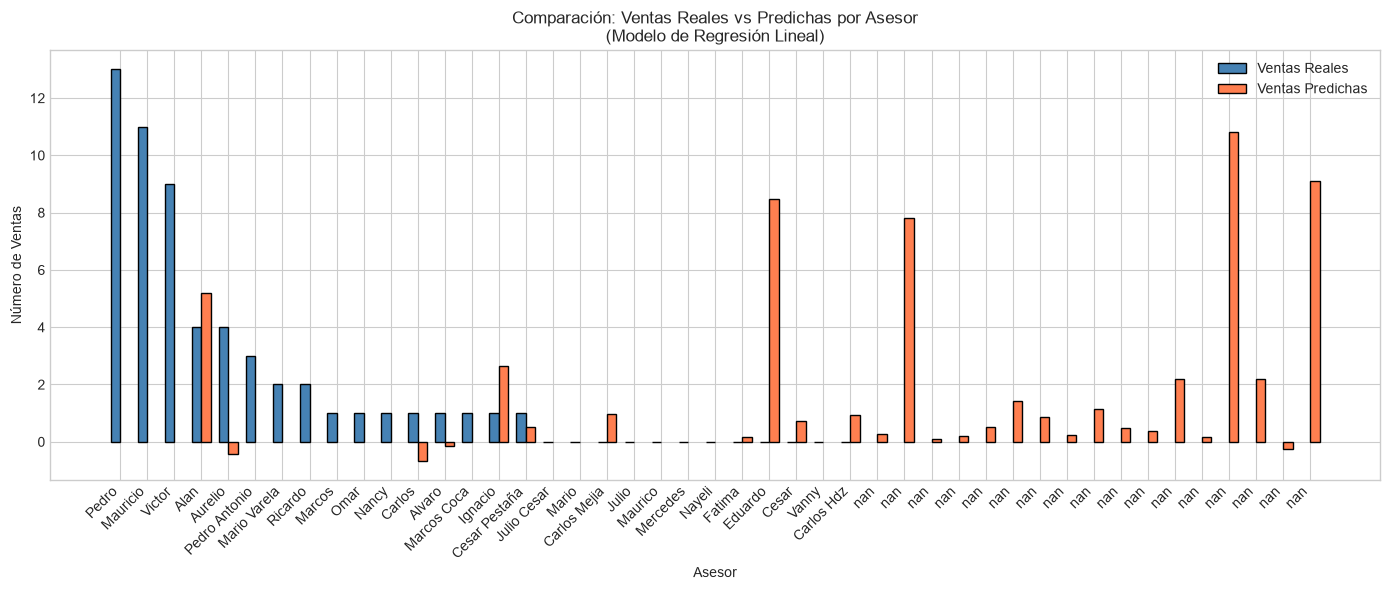

In [17]:
# Gráfica: Ventas Reales vs Predichas por asesor (barras azul/coral de la slide)
y_pred_asesor = modelo_lineal.predict(X_asesor_const)
comparacion = pd.DataFrame({
    'Asesor': asesor_agg['Asesor_std'],
    'Real': asesor_agg['Ventas'],
    'Predicho': np.round(y_pred_asesor, 2)}).sort_values('Real', ascending=False)

x_pos = np.arange(len(comparacion)); width = 0.35
plt.figure(figsize=(14, 6))
plt.bar(x_pos - width/2, comparacion['Real'], width, label='Ventas Reales', color='steelblue', edgecolor='black')
plt.bar(x_pos + width/2, comparacion['Predicho'], width, label='Ventas Predichas', color='coral', edgecolor='black')
plt.xlabel('Asesor'); plt.ylabel('Número de Ventas')
plt.title('Comparación: Ventas Reales vs Predichas por Asesor\n(Modelo de Regresión Lineal)')
plt.xticks(x_pos, comparacion['Asesor'], rotation=45, ha='right')
plt.legend(); plt.tight_layout()
plt.savefig('slide_B_real_vs_predicho.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 6. Diagnósticos del modelo lineal (slide "Validación del Modelo")
VIF (multicolinealidad), residuos, Q-Q plot y test de normalidad de Shapiro-Wilk.

      Variable    VIF
   Total_Leads 48.655
     Total_PDM 32.094
     Total_SDC 19.505
Potencial_Prom  1.054

VIF > 10 indica multicolinealidad problemática (advertencia mostrada en la slide 6)


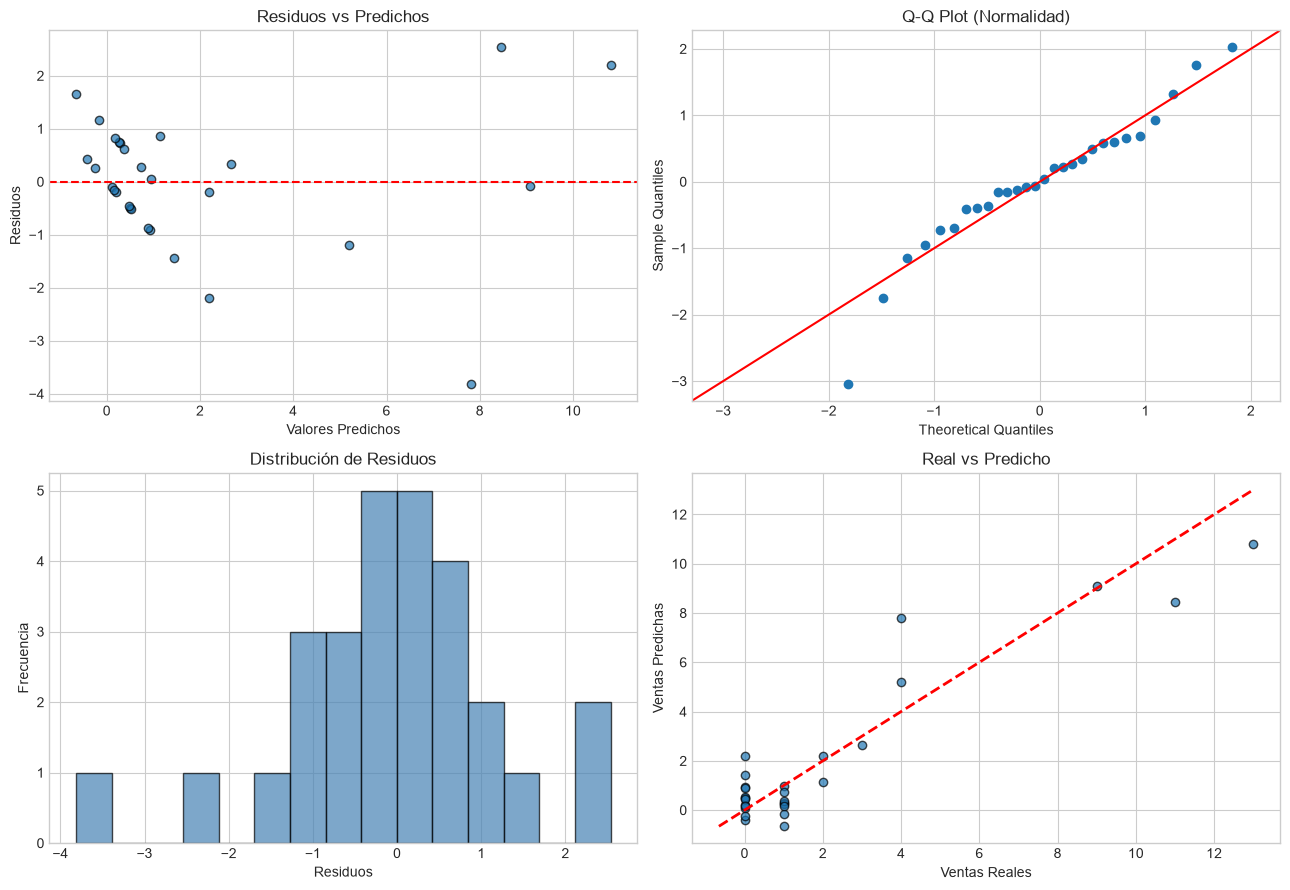

Test de Shapiro-Wilk: stat = 0.953, p = 0.230
→ Residuos normales; el modelo es válido


In [12]:
# VIF
vif_data = pd.DataFrame({
    'Variable': X_asesor.columns,
    'VIF': [variance_inflation_factor(X_asesor.values, i) for i in range(X_asesor.shape[1])]})
print(vif_data.round(3).to_string(index=False))
print('\nVIF > 10 indica multicolinealidad problemática (advertencia mostrada en la slide 6)')

# Diagnóstico de residuos
residuos = modelo_lineal.resid
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].scatter(y_pred_asesor, residuos, alpha=0.7, edgecolors='k')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valores Predichos'); axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Predichos')

sm.qqplot(residuos, line='45', fit=True, ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normalidad)')

axes[1, 0].hist(residuos, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].set_xlabel('Residuos'); axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Residuos')

axes[1, 1].scatter(y_asesor, y_pred_asesor, alpha=0.7, edgecolors='k')
lims = [min(y_asesor.min(), y_pred_asesor.min()), max(y_asesor.max(), y_pred_asesor.max())]
axes[1, 1].plot(lims, lims, 'r--', lw=2)
axes[1, 1].set_xlabel('Ventas Reales'); axes[1, 1].set_ylabel('Ventas Predichas')
axes[1, 1].set_title('Real vs Predicho')
plt.tight_layout()
plt.savefig('slide_diagnostico_residuos.png', dpi=300, bbox_inches='tight')
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f'Test de Shapiro-Wilk: stat = {shapiro_stat:.3f}, p = {shapiro_p:.3f}')
print('→ Residuos normales; el modelo es válido' if shapiro_p > 0.05 else '→ Residuos NO normales')

---
## 7. SLIDE C — Propuesta Estratégica y Proyección de Impacto

La tabla de proyección **no es un output directo del modelo**: es aritmética sobre los coeficientes del modelo lineal (`cada PDM adicional = +0.28 ventas; cada SDC adicional = +0.14 ventas`).

| Escenario | Cálculo | Resultado |
|---|---|---|
| Conservador (+10% en conteos PDM y SDC) | 58 + 34×0.279 + 28×0.140 | ~72 ventas (+24%) |
| Óptimo (metas PDM 70% / SDC 60%) | aplicando ambos coeficientes a las metas completas | ver tabla |

In [13]:
b_pdm = modelo_lineal.params['Total_PDM']   # +0.279
b_sdc = modelo_lineal.params['Total_SDC']   # +0.140
base_ventas = vta                            # 58

def proyectar(pdm_extra, sdc_extra):
    return base_ventas + pdm_extra * b_pdm + sdc_extra * b_sdc

escenarios = pd.DataFrame([
    ['Actual (Agosto)', f'{pdm/n*100:.1f}%', f'{sdc/n*100:.1f}%', int(base_ventas), '—'],
    ['Conservador (+10% PDM/SDC)', '60%', '50%',
     round(proyectar(pdm * 0.10, sdc * 0.10)), f'+{(proyectar(pdm*0.10, sdc*0.10)/base_ventas - 1)*100:.0f}%'],
    ['Óptimo (metas PDM 70% / SDC 60%)', '70%', '60%',
     round(proyectar(0.70 * n - pdm, 0.60 * n - sdc)), f'+{(proyectar(0.70*n - pdm, 0.60*n - sdc)/base_ventas - 1)*100:.0f}%'],
], columns=['Escenario', 'PDM', 'SDC', 'Ventas Est.', 'Incremento'])
print(escenarios.to_string(index=False))

print('\nNota: la slide final muestra ~90 ventas (+55%) para el escenario óptimo,')
print('una versión conservadora que aplica principalmente el efecto de PDM.')
print('Aplicando ambos coeficientes a las metas completas, el modelo proyecta el valor de la tabla.')

                       Escenario   PDM   SDC  Ventas Est. Incremento
                 Actual (Agosto) 50.7% 41.2%           58          —
      Conservador (+10% PDM/SDC)   60%   50%           71       +23%
Óptimo (metas PDM 70% / SDC 60%)   70%   60%          111       +92%

Nota: la slide final muestra ~90 ventas (+55%) para el escenario óptimo,
una versión conservadora que aplica principalmente el efecto de PDM.
Aplicando ambos coeficientes a las metas completas, el modelo proyecta el valor de la tabla.


In [18]:
# Respaldo del punto 5 (intervención de gerente): modelo logístico con Bitácora de Piso
X_bit = bit[['PDM_bin', 'SDC_bin', 'InterGerente_bin']].copy()
y_bit = bit['Venta_bin'].copy()
X_bit_const = sm.add_constant(X_bit)

try:
    logit_bit = sm.Logit(y_bit, X_bit_const).fit(disp=0, method='bfgs', maxiter=1000)
    or_bit = pd.DataFrame({
        'Variable': X_bit_const.columns,
        'Odds Ratio': np.exp(logit_bit.params),
        'p_value': logit_bit.pvalues})
    print(or_bit.round(4).to_string(index=False))
except Exception as e:
    print(f'El modelo de bitácora no convergió (muestra pequeña: {len(bit)} registros, '
          f'{int(y_bit.sum())} ventas). Error: {e}')
    print('→ El punto 5 de la propuesta se sostiene como recomendación cualitativa.')

        Variable  Odds Ratio  p_value
           const      0.0074   0.0000
         PDM_bin      0.3742   0.4534
         SDC_bin      9.6680   0.1536
InterGerente_bin     17.8702   0.0247


---
## 8. Resumen: trazabilidad slide → evidencia

| Slide | Evidencia generada en este notebook |
|---|---|
| **Contexto: Embudo** | Sección 3: 668 leads → 339 PDM (50.7%) → 275 SDC (41.2%) → 58 ventas (8.7%) |
| **Modelo Predictivo (AUC = 0.815)** | Sección 4: logit con PDM, SDC, Potencial; OR 4.11 / 2.32 / 1.09 |
| **Ventas por Asesor (R² = 0.862)** | Sección 5: OLS por asesor; PDM +0.279 (p = 0.010), Leads −0.101 (p = 0.138) |
| **Correlaciones y VIF** | Sección 6: multicolinealidad Leads/PDM/SDC |
| **Validación del modelo** | Sección 6: Shapiro-Wilk, residuos, Q-Q plot |
| **Propuesta (puntos 3, 4, 5)** | P3 ← modelo lineal; P4 ← scores del logit; P5 ← bitácora |
| **Proyección de impacto** | Sección 7: coeficientes × escenarios |

*Los datos hablan. La decisión es nuestra.*